In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

1.	Первый шаг – загрузить данные и убедиться, что всё считалось правильно: посмотреть на столбцы, размер, наличие пропущенных значений (если есть – удалить). Также изучите типы переменных.

In [32]:
df = pd.read_csv('C:/Users/majkl/WorkSpace/Project_st_1/games.csv')
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [34]:
# Удаление строк с пропущенными значениями
df.dropna(inplace=True)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  float64
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


2.	Постройте график распределения количества выпущенных игр по годам и выведите описательные характеристики переменной Year.

In [ ]:
#Описательная характеристика столбца Year
df.Year.describe()

count    16291.000000
mean      2006.405561
std          5.832412
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2020.000000
Name: Year, dtype: float64

In [40]:
Year_count = df.groupby('Year') \
    .agg({'Name': 'count'}) \
    .sort_values('Year') \
    .rename(columns={'Name': 'count'})

In [41]:
Year_count

,count
Year,
1980.0,9
1981.0,46
1982.0,36
1983.0,17
1984.0,14
1985.0,14
1986.0,21
1987.0,16
1988.0,15


C:\Users\majkl\AppData\Local\Temp\ipykernel_30936\2712702350.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=Year_count ,x='Year', y='count', palette='plasma')


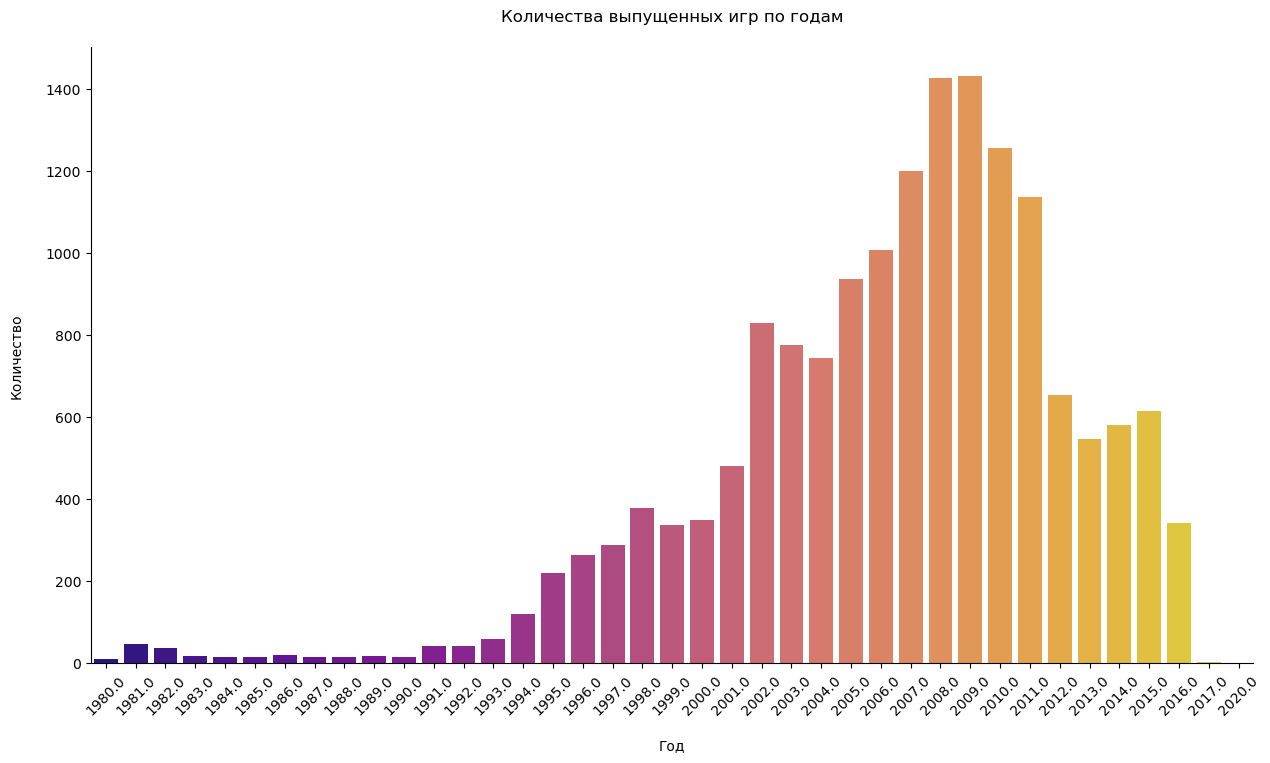

In [50]:
#Строим график
fig = plt.figure(figsize=(15,8))
ax = sns.barplot(data=Year_count ,x='Year', y='count', palette='plasma')
ax.set_title('Количества выпущенных игр по годам\n')
ax.set_ylabel('Количество\n') 
ax.set_xlabel('\nГод')
plt.xticks(rotation=45) 
sns.despine()

3.	На каких платформах произошло больше всего релизов?

In [58]:
df.Platform.unique()


array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       '3DS', 'PS4', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne', 'GC',
       'WiiU', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [59]:
df.Platform.nunique()

31

C:\Users\majkl\AppData\Local\Temp\ipykernel_30936\3139250263.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_Platform.iloc[:15], orient="h", palette='plasma')


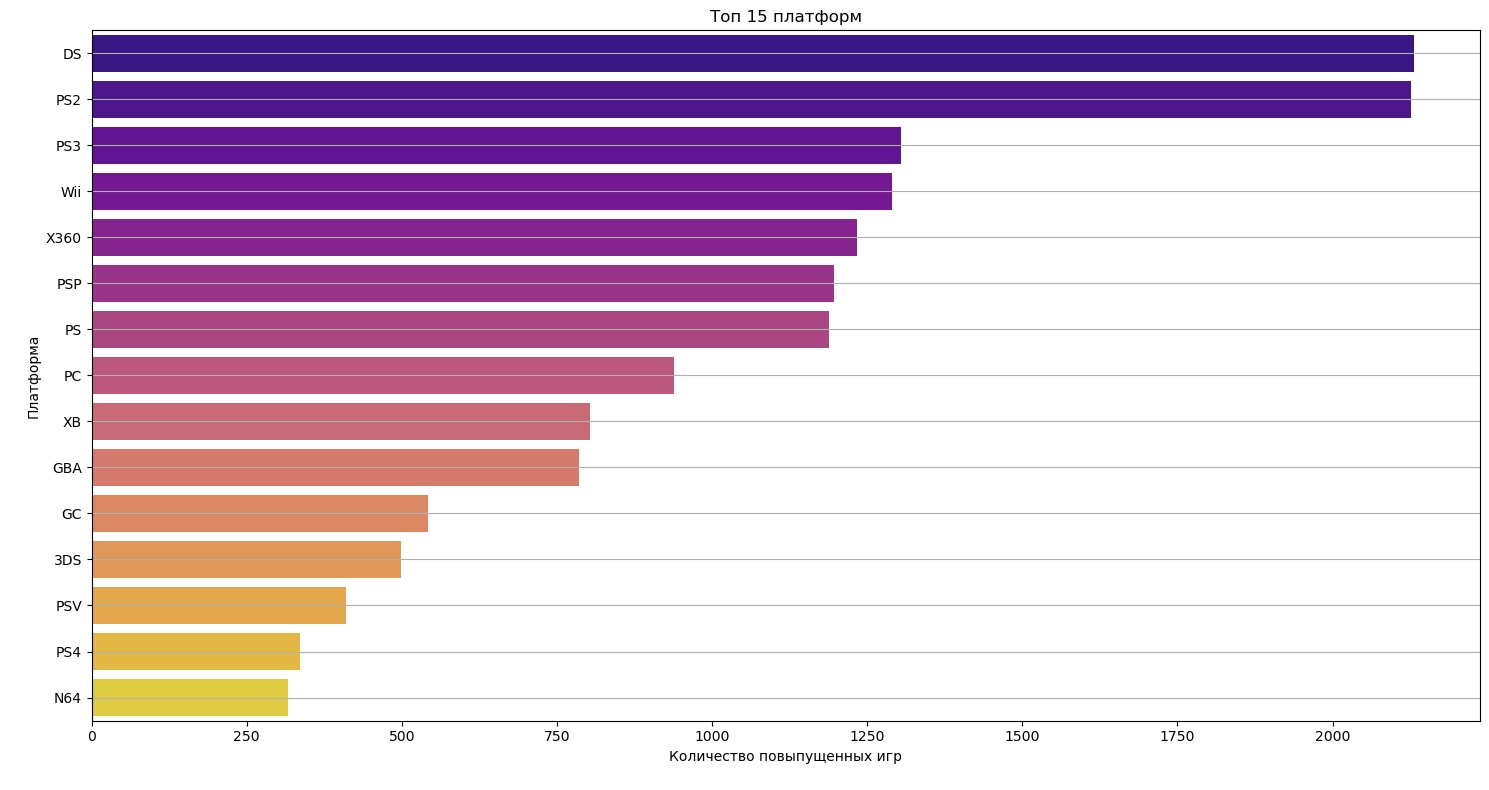

In [64]:
top_Platform = df.Platform.value_counts()
# Построение графика
plt.figure(figsize=(15, 8))
sns.barplot(data=top_Platform.iloc[:15], orient="h", palette='plasma')
plt.title('Топ 15 платформ')
plt.xlabel('Количество повыпущенных игр\n')
plt.ylabel('\nПлатформа')
plt.xticks(rotation=0)
plt.grid(axis='y')

# Показать график
plt.tight_layout()
plt.show()

In [61]:
top_Platform.iloc[:15]

Platform
DS      2131
PS2     2127
PS3     1304
Wii     1290
X360    1234
PSP     1197
PS      1189
PC       938
XB       803
GBA      786
GC       542
3DS      499
PSV      410
PS4      336
N64      316
Name: count, dtype: int64

4.	Игры каких издателей (Publisher) встречаются в датасете чаще всего?

In [ ]:
df.Publisher.unique()

array(['Nintendo', 'Microsoft Game Studios', 'Take-Two Interactive',
       'Sony Computer Entertainment', 'Activision', 'Ubisoft',
       'Bethesda Softworks', 'Electronic Arts', 'Sega', 'SquareSoft',
       'Atari', '505 Games', 'Capcom', 'GT Interactive',
       'Konami Digital Entertainment',
       'Sony Computer Entertainment Europe', 'Square Enix', 'LucasArts',
       'Virgin Interactive', 'Warner Bros. Interactive Entertainment',
       'Universal Interactive', 'Eidos Interactive', 'RedOctane',
       'Vivendi Games', 'Enix Corporation', 'Namco Bandai Games',
       'Palcom', 'Hasbro Interactive', 'THQ', 'Fox Interactive',
       'Acclaim Entertainment', 'MTV Games', 'Disney Interactive Studios',
       'Majesco Entertainment', 'Codemasters', 'Red Orb', 'Level 5',
       'Arena Entertainment', 'Midway Games', 'JVC', 'Deep Silver',
       '989 Studios', 'NCSoft', 'UEP Systems', 'Parker Bros.', 'Maxis',
       'Imagic', 'Tecmo Koei', 'Valve Software', 'ASCII Entertainment',
     

In [63]:
df.Publisher.nunique()

576

C:\Users\majkl\AppData\Local\Temp\ipykernel_30936\3911462077.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_Publisher.iloc[:15], orient="h", palette='plasma')


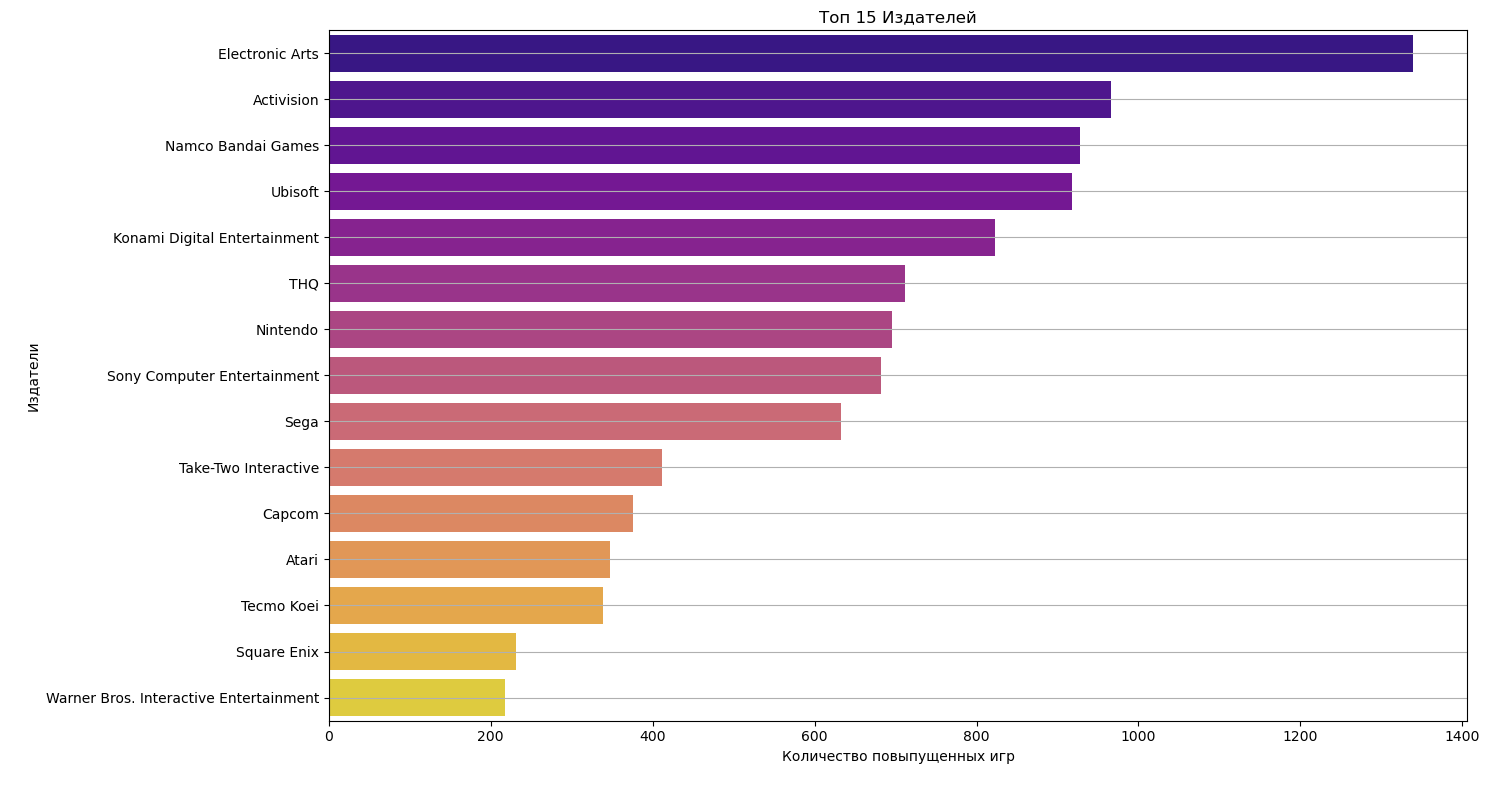

In [66]:
top_Publisher = df.Publisher.value_counts()
# Построение графика
plt.figure(figsize=(15, 8))
sns.barplot(data=top_Publisher.iloc[:15], orient="h", palette='plasma')
plt.title('Топ 15 Издателей')
plt.xlabel('Количество повыпущенных игр\n')
plt.ylabel('\nИздатели')
plt.xticks(rotation=0)
plt.grid(axis='y')

# Показать график
plt.tight_layout()
plt.show()

In [67]:
top_Publisher.iloc[:15]

Publisher
Electronic Arts                           1339
Activision                                 966
Namco Bandai Games                         928
Ubisoft                                    918
Konami Digital Entertainment               823
THQ                                        712
Nintendo                                   696
Sony Computer Entertainment                682
Sega                                       632
Take-Two Interactive                       412
Capcom                                     376
Atari                                      347
Tecmo Koei                                 338
Square Enix                                231
Warner Bros. Interactive Entertainment     217
Name: count, dtype: int64

5.	В каком регионе медианное значение объема продаж игр Nintendo является наибольшим? (Регионы: NA, EU, JP, Other)

In [68]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [77]:
median = df[df['Publisher'] == 'Nintendo']
median.shape

(696, 11)

In [86]:
median = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].median()
median.sort_values(ascending=False) 

NA_Sales       0.08
EU_Sales       0.02
Other_Sales    0.01
JP_Sales       0.00
dtype: float64

Наибольшее Медианное значение объема продаж игр Nintendo в регионе NA 

6.	Изучите объемы продаж игр Nintendo в Японии с разбивкой жанрам. Посмотрите на медиану, среднее, межквартильный размах.

In [112]:
JP = df.query("Publisher == 'Nintendo'")
med = JP.JP_Sales.median()#медиана
mean = JP.JP_Sales.mean()#среднее
iqr_value = stats.iqr(JP.JP_Sales) # межквартильный размах
print(f'Медиана: {med} \
      Среднее: {mean.round(2)} \
      Межквартильный размах: {iqr_value} \
      ')

Медиана: 0.28       Среднее: 0.65       Межквартильный размах: 0.65       


In [ ]:
JP = df[['Genre', 'JP_Sales']].groupby('Genre') \
    .agg({'JP_Sales': 'count'}) \
    .rename(columns={'JP_Sales': 'count'}) \
    .sort_values('count', ascending= False)
JP

,count
Genre,
Action,3251
Sports,2304
Misc,1686
Role-Playing,1470
Shooter,1282
Adventure,1274
Racing,1225
Platform,875
Simulation,848


C:\Users\majkl\AppData\Local\Temp\ipykernel_30936\4239725031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=JP, x='Genre', y='count', palette='plasma')


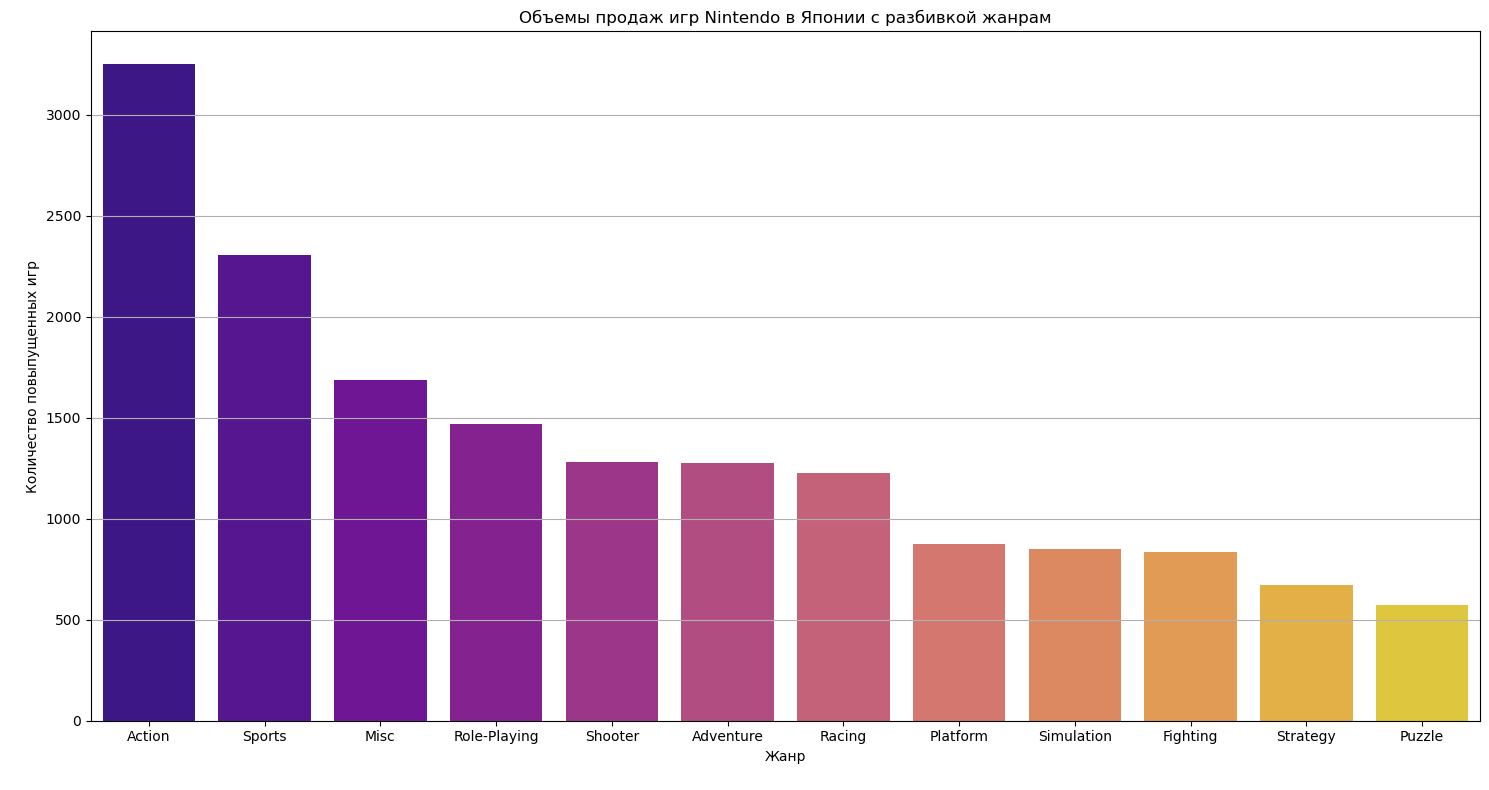

In [98]:
# Построение графика
plt.figure(figsize=(15, 8))
sns.barplot(data=JP, x='Genre', y='count', palette='plasma')
plt.title('Объемы продаж игр Nintendo в Японии с разбивкой жанрам')
plt.xlabel('Жанр\n')
plt.ylabel('\nКоличество повыпущенных игр')
plt.xticks(rotation=0)
plt.grid(axis='y')

# Показать график
plt.tight_layout()
plt.show()

7.	Визуализируйте динамику изменения объема мировых продаж (Global_Sales) по годам для игр Nintendo следующих жанров: Fighting, Simulation, Platform, Racing, Sports. В какие моменты времени было продано больше всего игр жанра Sports?

In [117]:
genre_jp = ['Fighting', 'Simulation', 'Platform', 'Racing', 'Sports']
JP = JP[JP['Genre'].isin(genre_jp)]

In [130]:
JP_gr = JP.groupby(['Year', 'Genre'], as_index=False).Global_Sales.sum()


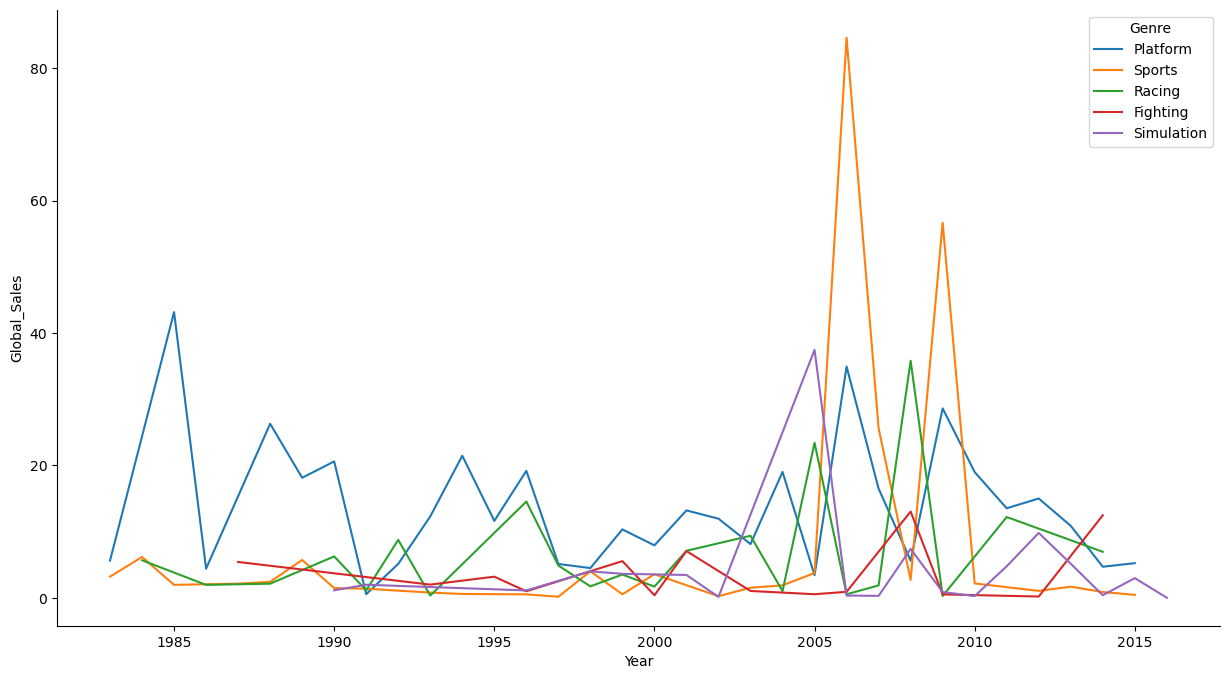

In [131]:
plt.figure(figsize=(15,8))
sns.lineplot(x = JP_gr.Year, y = JP_gr.Global_Sales, hue = JP_gr.Genre, data = JP_gr)
sns.despine()

В период 2005-2010 годов виден всплеск с самымы масштабными продажами игр категории Спорт